In [2]:
## importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

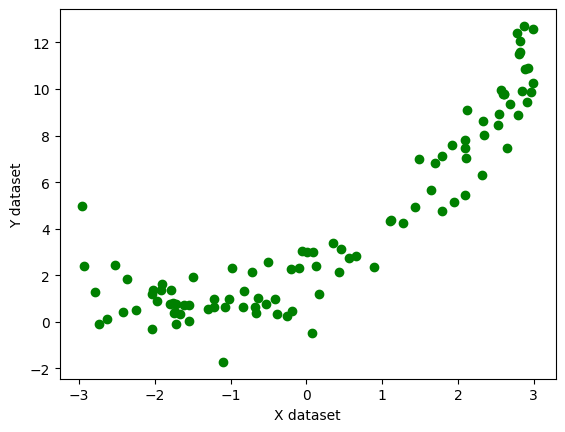

In [ ]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100, 1)
# quadratic equation used:- y = 0.5x^2 + 1.5x + 2 + outliers

plt.scatter(X, y, color="g")
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
## Let's now implement Simple Linear Regression
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

In [10]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.7070996681757777


Text(0, 0.5, 'Y dataset')

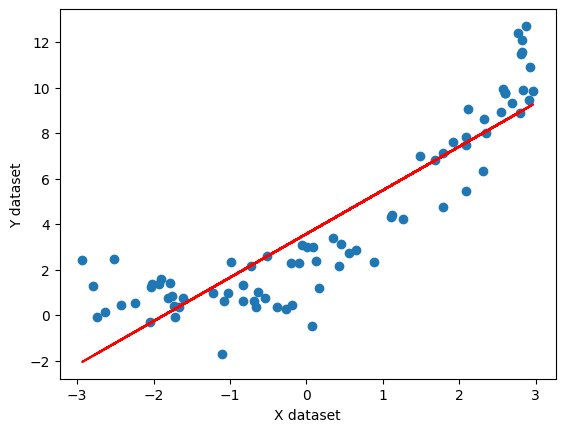

In [ ]:
# Let's visualize this model
plt.plot(X_train, regression_1.predict(X_train), color="r")
plt.scatter(X_train, y_train)
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [13]:
## Let's apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [14]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [15]:
X_train_poly

array([[ 1.00000000e+00,  1.64957937e-01,  2.72111211e-02],
       [ 1.00000000e+00,  1.68997240e+00,  2.85600671e+00],
       [ 1.00000000e+00, -1.90583208e+00,  3.63219592e+00],
       [ 1.00000000e+00,  1.31607306e-01,  1.73204831e-02],
       [ 1.00000000e+00,  5.62799746e-01,  3.16743554e-01],
       [ 1.00000000e+00,  2.09276910e+00,  4.37968249e+00],
       [ 1.00000000e+00,  7.73003502e-02,  5.97534413e-03],
       [ 1.00000000e+00,  1.10734129e+00,  1.22620473e+00],
       [ 1.00000000e+00, -1.73501639e+00,  3.01028189e+00],
       [ 1.00000000e+00, -1.09808429e+00,  1.20578912e+00],
       [ 1.00000000e+00, -5.13645449e-01,  2.63831647e-01],
       [ 1.00000000e+00, -2.78583280e+00,  7.76086440e+00],
       [ 1.00000000e+00,  2.34804119e+00,  5.51329745e+00],
       [ 1.00000000e+00, -6.63563960e-01,  4.40317129e-01],
       [ 1.00000000e+00,  2.82225853e+00,  7.96514319e+00],
       [ 1.00000000e+00,  2.60351904e+00,  6.77831140e+00],
       [ 1.00000000e+00,  2.56966995e+00

In [16]:
X_test_poly

array([[ 1.        ,  2.99131687,  8.94797662],
       [ 1.        ,  1.64061272,  2.69161011],
       [ 1.        , -1.71540855,  2.94262648],
       [ 1.        ,  2.53209807,  6.41152066],
       [ 1.        , -1.55679176,  2.4236006 ],
       [ 1.        , -2.36221858,  5.58007661],
       [ 1.        , -1.75235001,  3.07073056],
       [ 1.        , -2.95986511,  8.76080149],
       [ 1.        , -1.55325314,  2.41259533],
       [ 1.        , -0.42095923,  0.17720668],
       [ 1.        ,  2.65034493,  7.02432825],
       [ 1.        ,  2.88584922,  8.32812573],
       [ 1.        , -1.97729604,  3.90969963],
       [ 1.        , -1.22327961,  1.49641301],
       [ 1.        ,  1.43738518,  2.06607614],
       [ 1.        ,  1.95356426,  3.81641332],
       [ 1.        ,  2.10269224,  4.42131466],
       [ 1.        ,  2.98644393,  8.91884733],
       [ 1.        , -1.49531127,  2.2359558 ],
       [ 1.        , -1.29364541,  1.67351845]])

In [ ]:
from sklearn.metrics import r2_score

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9113789490751175


In [18]:
print(regression.coef_)

[[0.         1.61844034 0.52272439]]


In [19]:
print(regression.intercept_)

[1.84841161]


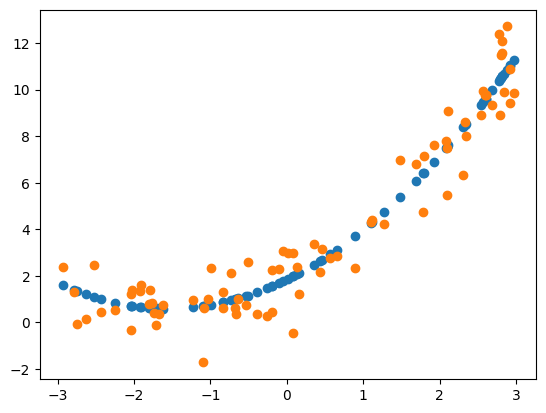

In [21]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [22]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
X_train_poly

array([[ 1.00000000e+00,  1.64957937e-01,  2.72111211e-02,
         4.48869042e-03],
       [ 1.00000000e+00,  1.68997240e+00,  2.85600671e+00,
         4.82657251e+00],
       [ 1.00000000e+00, -1.90583208e+00,  3.63219592e+00,
        -6.92235551e+00],
       [ 1.00000000e+00,  1.31607306e-01,  1.73204831e-02,
         2.27950212e-03],
       [ 1.00000000e+00,  5.62799746e-01,  3.16743554e-01,
         1.78263191e-01],
       [ 1.00000000e+00,  2.09276910e+00,  4.37968249e+00,
         9.16566416e+00],
       [ 1.00000000e+00,  7.73003502e-02,  5.97534413e-03,
         4.61896194e-04],
       [ 1.00000000e+00,  1.10734129e+00,  1.22620473e+00,
         1.35782713e+00],
       [ 1.00000000e+00, -1.73501639e+00,  3.01028189e+00,
        -5.22288843e+00],
       [ 1.00000000e+00, -1.09808429e+00,  1.20578912e+00,
        -1.32405809e+00],
       [ 1.00000000e+00, -5.13645449e-01,  2.63831647e-01,
        -1.35515925e-01],
       [ 1.00000000e+00, -2.78583280e+00,  7.76086440e+00,
      

In [ ]:
from sklearn.metrics import r2_score

regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9092723047019801


In [ ]:
## Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

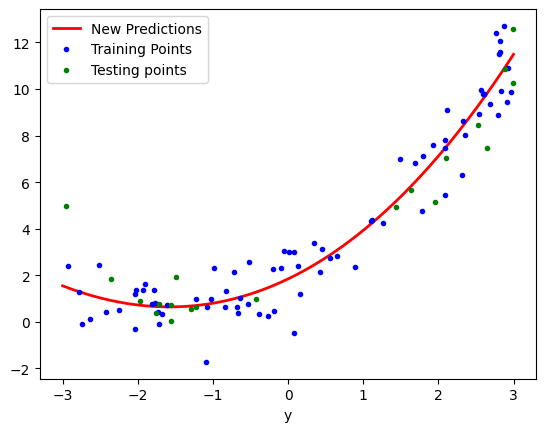

In [ ]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.", label="Training Points")
plt.plot(X_test, y_test, "g.", label="Testing points")
plt.xlabel("X")
plt.xlabel("y")
plt.legend()
plt.show()

### Pipeline Concepts


In [29]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    X_new_poly = poly.transform(X_new)
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([("poly_features", poly_features), ("lin_reg", lin_reg)])
    poly_regression.fit(X_train, y_train)  ## polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)

    # Ploting prediction line
    plt.plot(X_new, y_pred_new, "r", label="Degree" + str(degree), linewidth=3)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.xlabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

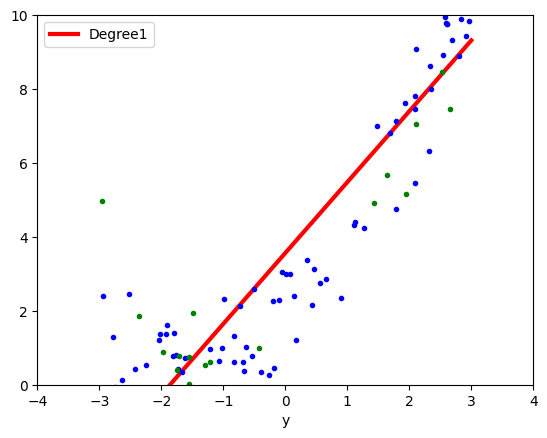

In [41]:
poly_regression(1)

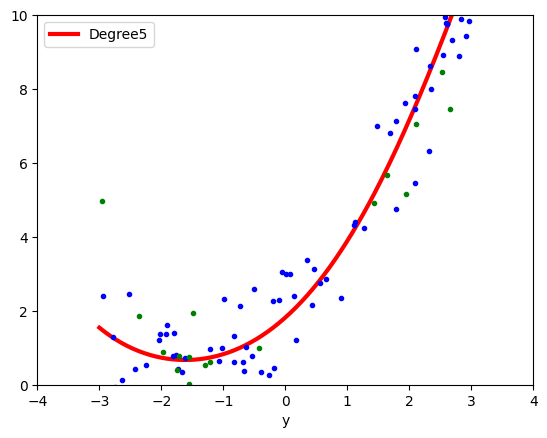

In [42]:
poly_regression(5)

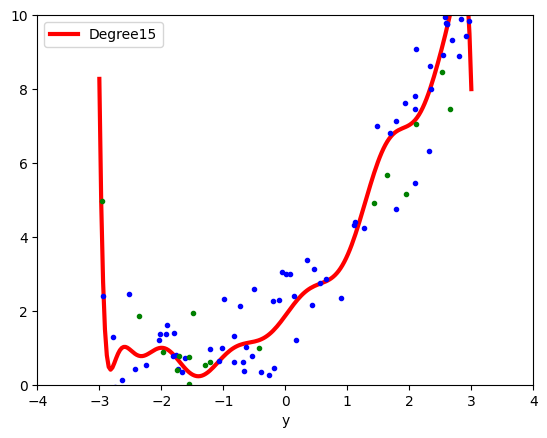

In [43]:
poly_regression(15)

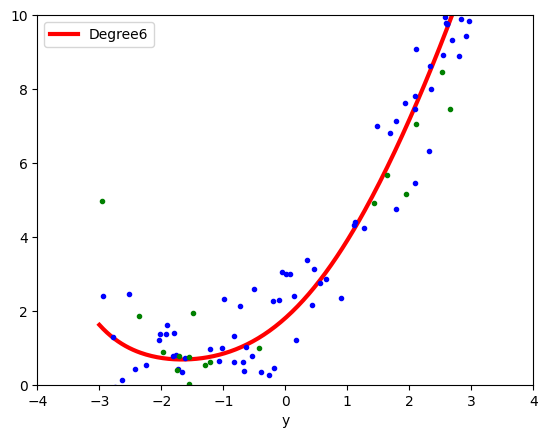

In [44]:
poly_regression(6)